# Gaussian Mixture Models & the EM Algorithm

---

## Table of Contents
1. [The Generative Model](#1-the-generative-model)
2. [The Likelihood & Why It's Hard to Maximise](#2-the-likelihood)
3. [The EM Algorithm — E-step and M-step](#3-the-em-algorithm)
4. [Derivation — Why EM Works (Jensen's Inequality)](#4-why-em-works)
5. [GMM vs K-Means — Soft vs Hard Assignments](#5-gmm-vs-k-means)
6. [Model Selection — BIC & AIC](#6-model-selection)
7. [Practical Considerations & Limitations](#7-practical-considerations)

---

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import multivariate_normal
from sklearn.mixture import GaussianMixture
from sklearn.datasets import make_blobs
import os

os.makedirs('img', exist_ok=True)

plt.rcParams.update({
    'figure.facecolor': '#0f0f0f', 'axes.facecolor': '#1a1a1a',
    'axes.edgecolor': '#444', 'axes.labelcolor': '#ccc',
    'xtick.color': '#888', 'ytick.color': '#888', 'text.color': '#eee',
    'grid.color': '#2a2a2a', 'grid.linewidth': 0.8,
    'font.family': 'monospace', 'axes.titlesize': 12, 'axes.labelsize': 11,
})
ACCENT = '#00e5ff'
ORANGE = '#ff6d00'
GREEN  = '#69ff47'
RED    = '#ff4d6d'
PURPLE = '#c77dff'
YELLOW = '#ffd60a'
CLUSTER_COLORS = [ACCENT, ORANGE, GREEN, RED, PURPLE]

---
## 1. The Generative Model

A Gaussian Mixture Model (GMM) assumes each data point $x_i$ was generated by:
1. Sampling a **latent component** $z_i \in \{1, \ldots, K\}$ from a categorical distribution:
$$P(z_i = k) = \pi_k, \quad \sum_{k=1}^K \pi_k = 1, \quad \pi_k > 0$$
2. Given $z_i = k$, sampling $x_i$ from a Gaussian:
$$x_i \mid z_i = k \sim \mathcal{N}(\mu_k, \Sigma_k)$$

The **marginal distribution** of $x$ (integrating out the latent $z$):
$$p(x) = \sum_{k=1}^K \pi_k \, \mathcal{N}(x; \mu_k, \Sigma_k)$$

The model parameters are:
- $\pi_k$ — **mixing weights** (prior probability of component $k$)
- $\mu_k \in \mathbb{R}^p$ — **component mean**
- $\Sigma_k \in \mathbb{R}^{p \times p}$ — **component covariance**

Total parameters: $K-1$ (weights) $+ Kp$ (means) $+ K\frac{p(p+1)}{2}$ (covariances, symmetric).

### Covariance Constraints

Full $\Sigma_k$ allows arbitrary ellipses — most flexible but most parameters. Common constraints:

| `covariance_type` (sklearn) | $\Sigma_k$ | Shape |
|---|---|---|
| `'full'` | Unrestricted $\Sigma_k$ per component | Arbitrary ellipse |
| `'tied'` | Shared $\Sigma$ across components | Same ellipse, different centres |
| `'diag'` | Diagonal $\Sigma_k$ | Axis-aligned ellipse |
| `'spherical'` | $\sigma_k^2 I$ | Circle/sphere |

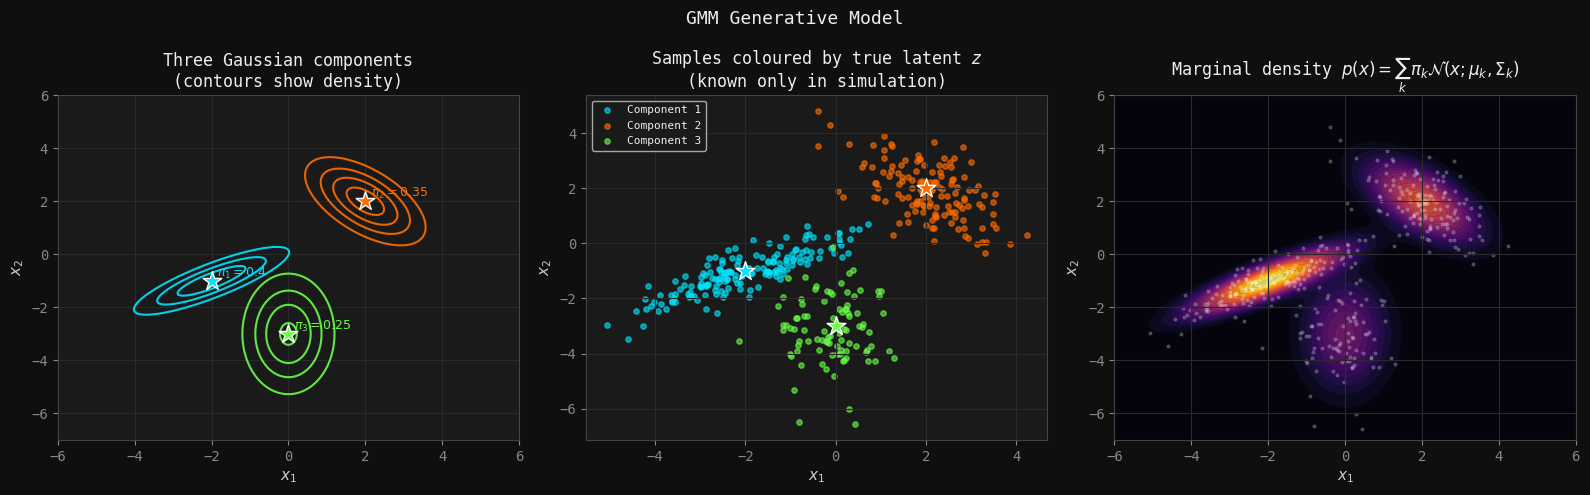

In [2]:
np.random.seed(0)

# Define a GMM and show the generative process
pi  = np.array([0.4, 0.35, 0.25])
mus = [np.array([-2, -1]), np.array([2, 2]), np.array([0, -3])]
Sigmas = [
    np.array([[1.5, 0.8],[0.8, 0.6]]),
    np.array([[0.8,-0.5],[-0.5,0.9]]),
    np.array([[0.5, 0.0],[0.0, 1.8]]),
]

# Sample from the GMM
n_samples = 400
z_samples = np.random.choice(3, size=n_samples, p=pi)
X_gmm = np.array([np.random.multivariate_normal(mus[z], Sigmas[z]) for z in z_samples])

xi = np.linspace(-6, 6, 200)
yi = np.linspace(-7, 6, 200)
Xi, Yi = np.meshgrid(xi, yi)
pos = np.dstack((Xi, Yi))

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('GMM Generative Model', fontsize=13)

# Component Gaussians
ax = axes[0]
for k in range(3):
    rv = multivariate_normal(mus[k], Sigmas[k])
    Z_k = rv.pdf(pos)
    ax.contour(Xi, Yi, Z_k, levels=4, colors=[CLUSTER_COLORS[k]], linewidths=1.5, alpha=0.9)
    ax.scatter(*mus[k], color=CLUSTER_COLORS[k], s=200, marker='*', zorder=5,
               edgecolors='white', linewidth=1)
    ax.text(mus[k][0]+0.15, mus[k][1]+0.15,
            f'$\\pi_{k+1}={pi[k]}$', color=CLUSTER_COLORS[k], fontsize=9)
ax.set_title('Three Gaussian components\n(contours show density)')
ax.set_xlabel('$x_1$'); ax.set_ylabel('$x_2$'); ax.grid(True)

# Sampled data coloured by true component
ax = axes[1]
for k in range(3):
    mask = z_samples == k
    ax.scatter(X_gmm[mask,0], X_gmm[mask,1],
               color=CLUSTER_COLORS[k], s=15, alpha=0.6, label=f'Component {k+1}')
    ax.scatter(*mus[k], color=CLUSTER_COLORS[k], s=200, marker='*', zorder=5,
               edgecolors='white', linewidth=1)
ax.set_title('Samples coloured by true latent $z$\n(known only in simulation)')
ax.set_xlabel('$x_1$'); ax.set_ylabel('$x_2$'); ax.legend(fontsize=8); ax.grid(True)

# Marginal density p(x)
ax = axes[2]
Z_marg = sum(pi[k] * multivariate_normal(mus[k], Sigmas[k]).pdf(pos) for k in range(3))
ax.contourf(Xi, Yi, Z_marg, levels=30, cmap='inferno', alpha=0.85)
ax.scatter(X_gmm[:,0], X_gmm[:,1], c='white', s=4, alpha=0.2)
ax.set_title('Marginal density $p(x) = \\sum_k \\pi_k \\mathcal{N}(x;\\mu_k,\\Sigma_k)$')
ax.set_xlabel('$x_1$'); ax.set_ylabel('$x_2$'); ax.grid(True)

plt.tight_layout()
plt.savefig('img/gmm01_model.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 2. The Likelihood & Why It's Hard to Maximise

Given data $\mathcal{D} = \{x_1, \ldots, x_n\}$, the log-likelihood is:

$$\log p(\mathcal{D}) = \sum_{i=1}^n \log \left( \sum_{k=1}^K \pi_k \, \mathcal{N}(x_i; \mu_k, \Sigma_k) \right)$$

This has **no closed-form solution** because of the log-of-sum structure. Setting the gradient to zero gives:

$$\frac{\partial \log p}{\partial \mu_k} = \sum_{i=1}^n \frac{\pi_k \mathcal{N}(x_i;\mu_k,\Sigma_k)}{\sum_j \pi_j \mathcal{N}(x_i;\mu_j,\Sigma_j)} \Sigma_k^{-1}(x_i - \mu_k) = 0$$

Define the **posterior responsibility** of component $k$ for sample $i$:
$$r_{ik} = P(z_i = k \mid x_i) = \frac{\pi_k \mathcal{N}(x_i;\mu_k,\Sigma_k)}{\sum_j \pi_j \mathcal{N}(x_i;\mu_j,\Sigma_j)}$$

Then the gradient equation becomes:
$$\sum_{i=1}^n r_{ik}(x_i - \mu_k) = 0 \implies \mu_k = \frac{\sum_i r_{ik} x_i}{\sum_i r_{ik}}$$

But $r_{ik}$ depends on $\mu_k$, $\Sigma_k$, $\pi_k$ — so this is a **coupled system**. We can't solve for one parameter without knowing the others. This is exactly the structure that EM exploits.

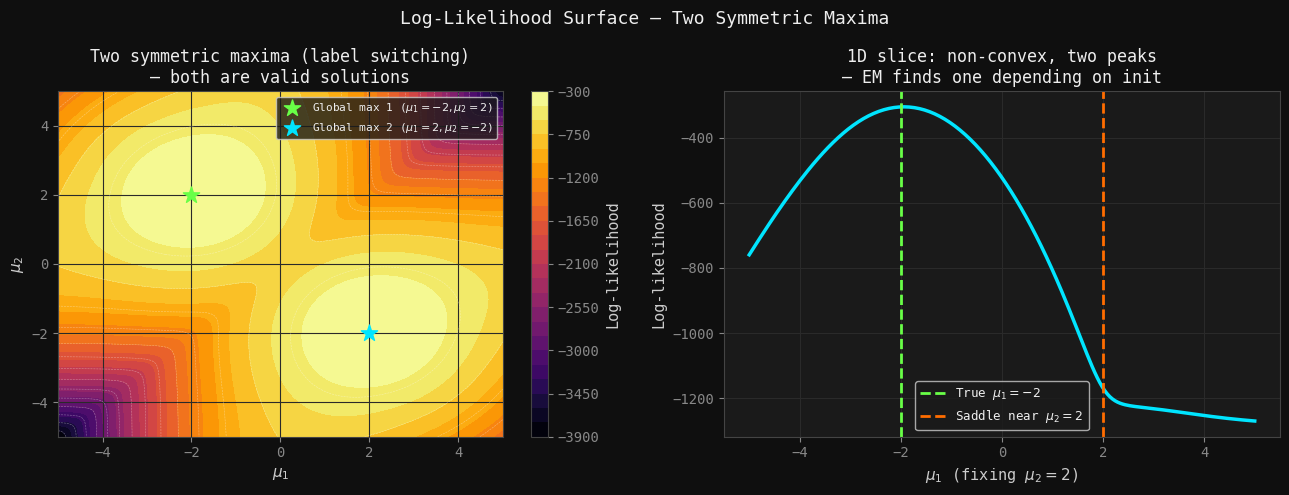

In [3]:
# Visualise the log-likelihood surface (1D GMM, 2 components, vary mu_1)
np.random.seed(5)
X_1d_gmm = np.concatenate([np.random.normal(-2, 0.8, 80),
                             np.random.normal(2, 0.8, 80)])

def gmm_loglik_1d(X, mu1, mu2=2.0, sigma=0.8, pi1=0.5):
    p1 = pi1 * (1/(sigma*np.sqrt(2*np.pi))) * np.exp(-0.5*((X-mu1)/sigma)**2)
    p2 = (1-pi1) * (1/(sigma*np.sqrt(2*np.pi))) * np.exp(-0.5*((X-mu2)/sigma)**2)
    return np.sum(np.log(p1 + p2 + 1e-300))

mu1_range = np.linspace(-5, 5, 200)
mu2_range = np.linspace(-5, 5, 200)
M1, M2 = np.meshgrid(mu1_range, mu2_range)
LL = np.array([[gmm_loglik_1d(X_1d_gmm, m1, m2)
                for m1 in mu1_range] for m2 in mu2_range])

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Log-Likelihood Surface — Two Symmetric Maxima', fontsize=13)

ax = axes[0]
cp = ax.contourf(M1, M2, LL, levels=30, cmap='inferno')
plt.colorbar(cp, ax=ax, label='Log-likelihood')
ax.contour(M1, M2, LL, levels=15, colors='white', linewidths=0.4, alpha=0.4)
# Mark the two symmetric maxima
ax.scatter(-2,  2, color=GREEN, s=150, zorder=5, marker='*', label='Global max 1 ($\\mu_1=-2, \\mu_2=2$)')
ax.scatter( 2, -2, color=ACCENT, s=150, zorder=5, marker='*', label='Global max 2 ($\\mu_1=2, \\mu_2=-2$)')
ax.set_xlabel('$\\mu_1$'); ax.set_ylabel('$\\mu_2$')
ax.set_title('Two symmetric maxima (label switching)\n— both are valid solutions')
ax.legend(fontsize=8); ax.grid(True)

ax = axes[1]
ax.plot(mu1_range, [gmm_loglik_1d(X_1d_gmm, m1) for m1 in mu1_range],
        color=ACCENT, lw=2.5)
ax.axvline(-2, color=GREEN,  lw=2, linestyle='--', label='True $\\mu_1=-2$')
ax.axvline( 2, color=ORANGE, lw=2, linestyle='--', label='Saddle near $\\mu_2=2$')
ax.set_xlabel('$\\mu_1$ (fixing $\\mu_2=2$)')
ax.set_ylabel('Log-likelihood')
ax.set_title('1D slice: non-convex, two peaks\n— EM finds one depending on init')
ax.legend(fontsize=9); ax.grid(True)

plt.tight_layout()
plt.savefig('img/gmm02_likelihood.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 3. The EM Algorithm — E-step and M-step

EM treats the latent assignments $z_i$ as **missing data** and alternates between:

### E-step — Compute Responsibilities

Compute the **posterior probability** that sample $i$ was generated by component $k$, given the current parameters $\theta^{(t)} = (\pi^{(t)}, \mu^{(t)}, \Sigma^{(t)})$:

$$r_{ik}^{(t)} = \frac{\pi_k^{(t)} \, \mathcal{N}(x_i; \mu_k^{(t)}, \Sigma_k^{(t)})}{\sum_{j=1}^K \pi_j^{(t)} \, \mathcal{N}(x_i; \mu_j^{(t)}, \Sigma_j^{(t)})}$$

Note: $\sum_k r_{ik} = 1$ for each $i$ — the responsibilities are a probability distribution over components.

### M-step — Update Parameters

Define the **effective number of points** in component $k$:
$$N_k = \sum_{i=1}^n r_{ik}$$

Update the parameters using the responsibilities as soft weights:

$$\pi_k^{(t+1)} = \frac{N_k}{n}$$

$$\mu_k^{(t+1)} = \frac{1}{N_k}\sum_{i=1}^n r_{ik} x_i$$

$$\Sigma_k^{(t+1)} = \frac{1}{N_k}\sum_{i=1}^n r_{ik}(x_i - \mu_k^{(t+1)})(x_i - \mu_k^{(t+1)})^\top$$

### K-Means as Hard EM

K-Means is EM with **hard assignments**: $r_{ik} \in \{0,1\}$ (one component gets all the responsibility). GMM generalises this to **soft assignments**: $r_{ik} \in [0,1]$ — a point can partially belong to multiple components.

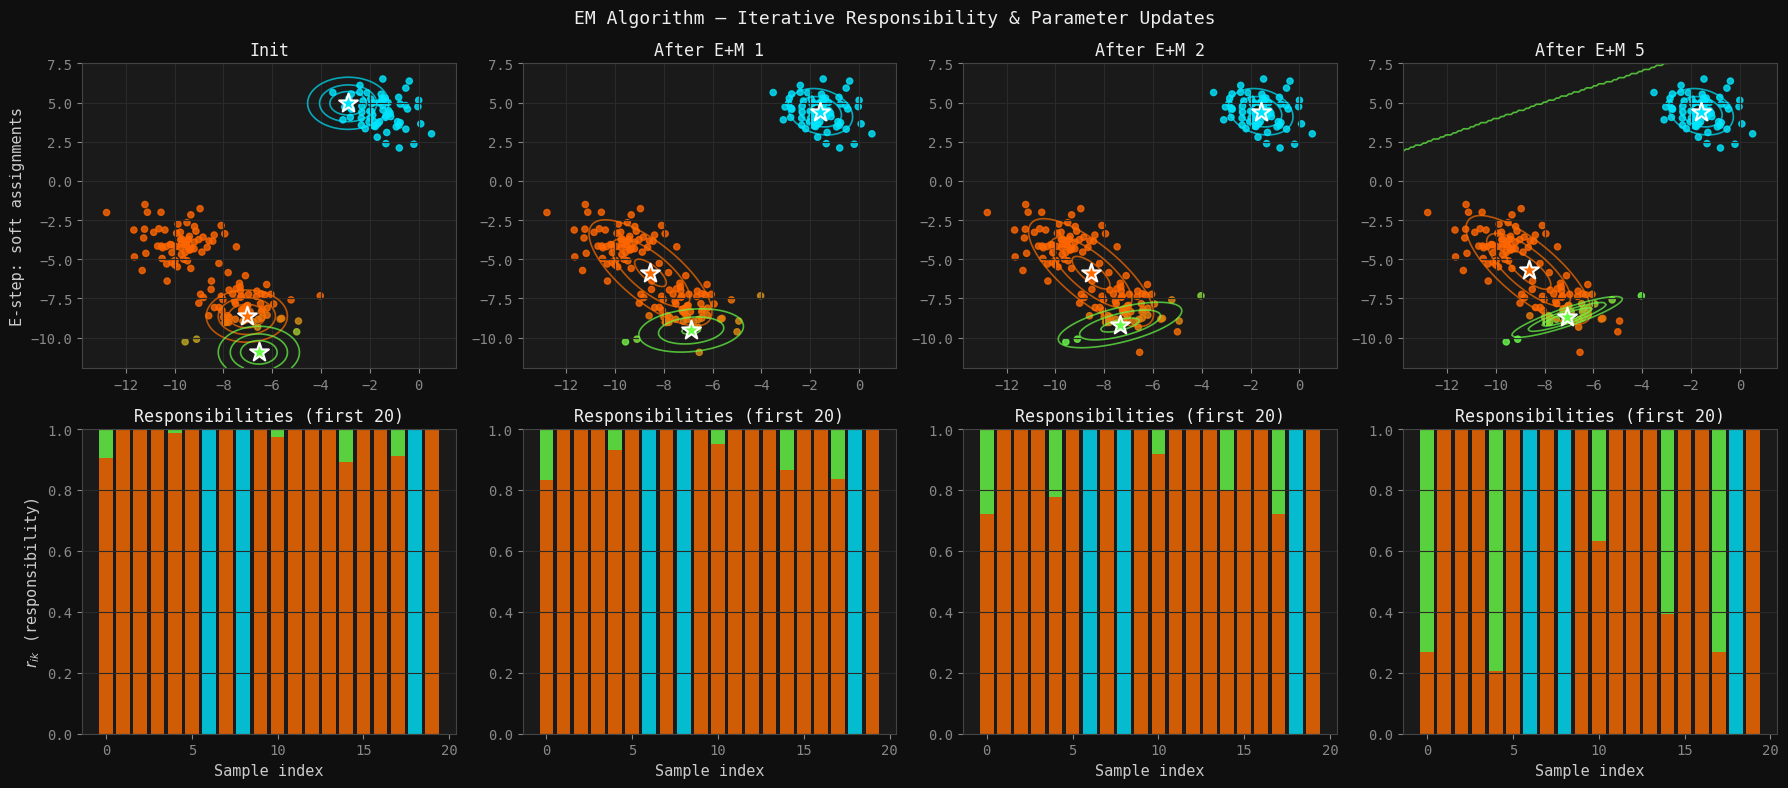

In [4]:
# Manual EM implementation for 2D GMM
np.random.seed(1)
X_em, _ = make_blobs(n_samples=200, centers=3, cluster_std=1.0, random_state=1)

K_em = 3
# Init
np.random.seed(3)
pi_em  = np.ones(K_em) / K_em
mu_em  = X_em[np.random.choice(len(X_em), K_em, replace=False)]
Sig_em = [np.eye(2) for _ in range(K_em)]

def e_step(X, pi, mu, Sig):
    n, K = len(X), len(pi)
    R = np.zeros((n, K))
    for k in range(K):
        R[:,k] = pi[k] * multivariate_normal(mu[k], Sig[k]).pdf(X)
    R /= R.sum(axis=1, keepdims=True) + 1e-300
    return R

def m_step(X, R):
    n, K = R.shape
    Nk = R.sum(axis=0)
    pi_new  = Nk / n
    mu_new  = [(R[:,k] @ X) / Nk[k] for k in range(K)]
    sig_new = []
    for k in range(K):
        diff = X - mu_new[k]
        sig_new.append((R[:,k:k+1] * diff).T @ diff / Nk[k])
    return pi_new, mu_new, sig_new

def log_likelihood(X, pi, mu, Sig):
    n, K = len(X), len(pi)
    ll = 0
    for i in range(n):
        ll += np.log(sum(pi[k]*multivariate_normal(mu[k],Sig[k]).pdf(X[i])
                         for k in range(K)) + 1e-300)
    return ll

ll_history = [log_likelihood(X_em, pi_em, mu_em, Sig_em)]
states = [(pi_em.copy(), [m.copy() for m in mu_em], [s.copy() for s in Sig_em])]
for t in range(10):
    R_em = e_step(X_em, pi_em, mu_em, Sig_em)
    pi_em, mu_em, Sig_em = m_step(X_em, R_em)
    ll_history.append(log_likelihood(X_em, pi_em, mu_em, Sig_em))
    if t in [0, 1, 4]:
        states.append((pi_em.copy(), [m.copy() for m in mu_em], [s.copy() for s in Sig_em]))

xi_em = np.linspace(X_em[:,0].min()-1, X_em[:,0].max()+1, 150)
yi_em = np.linspace(X_em[:,1].min()-1, X_em[:,1].max()+1, 150)
Xi_em, Yi_em = np.meshgrid(xi_em, yi_em)
pos_em = np.dstack((Xi_em, Yi_em))

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
fig.suptitle('EM Algorithm — Iterative Responsibility & Parameter Updates', fontsize=13)

for col, (t_label, (pi_s, mu_s, sig_s)) in enumerate(zip(
    ['Init', 'After E+M 1', 'After E+M 2', 'After E+M 5'],
    states
)):
    R_s = e_step(X_em, pi_s, mu_s, sig_s)
    # Top: soft-coloured scatter (colour = weighted blend)
    ax = axes[0][col]
    colors_blend = R_s @ np.array([[0,0.9,1],[1,0.4,0],[0.4,1,0.3]])
    colors_blend = np.clip(colors_blend, 0, 1)
    ax.scatter(X_em[:,0], X_em[:,1], c=colors_blend, s=20, alpha=0.8)
    for k in range(K_em):
        ax.scatter(*mu_s[k], color=CLUSTER_COLORS[k], s=200,
                   marker='*', zorder=5, edgecolors='white', linewidth=1.5)
        try:
            rv_k = multivariate_normal(mu_s[k], sig_s[k])
            Z_k  = rv_k.pdf(pos_em)
            ax.contour(Xi_em, Yi_em, Z_k, levels=3,
                       colors=[CLUSTER_COLORS[k]], linewidths=1.2, alpha=0.7)
        except: pass
    ax.set_title(t_label); ax.grid(True)
    if col == 0: ax.set_ylabel('E-step: soft assignments')

    # Bottom: responsibility bar per sample (first 20)
    ax = axes[1][col]
    n_show = 20
    bottom = np.zeros(n_show)
    for k in range(K_em):
        ax.bar(range(n_show), R_s[:n_show, k], bottom=bottom,
               color=CLUSTER_COLORS[k], alpha=0.8)
        bottom += R_s[:n_show, k]
    ax.set_ylim(0, 1); ax.set_xlabel('Sample index')
    if col == 0: ax.set_ylabel('$r_{ik}$ (responsibility)')
    ax.set_title(f'Responsibilities (first {n_show})')
    ax.grid(True, axis='y')

plt.tight_layout()
plt.savefig('img/gmm03_em_steps.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 4. Derivation — Why EM Works (Jensen's Inequality)

EM is guaranteed to increase (or maintain) the log-likelihood at every iteration. Here is the core argument.

### The ELBO

Introduce an arbitrary distribution $q(z)$ over latent variables. We can write:
$$\log p(x) = \log \sum_z p(x, z) = \log \sum_z q(z) \frac{p(x,z)}{q(z)}$$

Apply **Jensen's inequality** — for a concave function $f$ (log is concave) and a distribution $q$:
$$f\!\left(\mathbb{E}_q[X]\right) \geq \mathbb{E}_q[f(X)]$$

$$\log p(x) = \log \mathbb{E}_{q(z)}\!\left[\frac{p(x,z)}{q(z)}\right] \geq \mathbb{E}_{q(z)}\!\left[\log\frac{p(x,z)}{q(z)}\right] = \mathcal{L}(q, \theta)$$

$\mathcal{L}(q, \theta)$ is the **Evidence Lower BOund (ELBO)**. The gap between $\log p(x)$ and the ELBO is exactly the KL divergence:
$$\log p(x) = \mathcal{L}(q,\theta) + D_{KL}(q(z) \| p(z|x,\theta))$$

### E-step Maximises ELBO over $q$

Set $q(z_i) = p(z_i | x_i, \theta^{(t)})$ — the current posterior. This makes $D_{KL} = 0$ (the ELBO is tight). In GMM this is exactly computing the responsibilities $r_{ik}$.

### M-step Maximises ELBO over $\theta$

With $q$ fixed, maximise $\mathcal{L}(q, \theta)$ over $\theta$. Because the ELBO is tight after the E-step, any increase in ELBO translates directly into an increase in $\log p(x)$.

Therefore: each EM iteration increases $\log p(x)$ — **monotone convergence is guaranteed**.

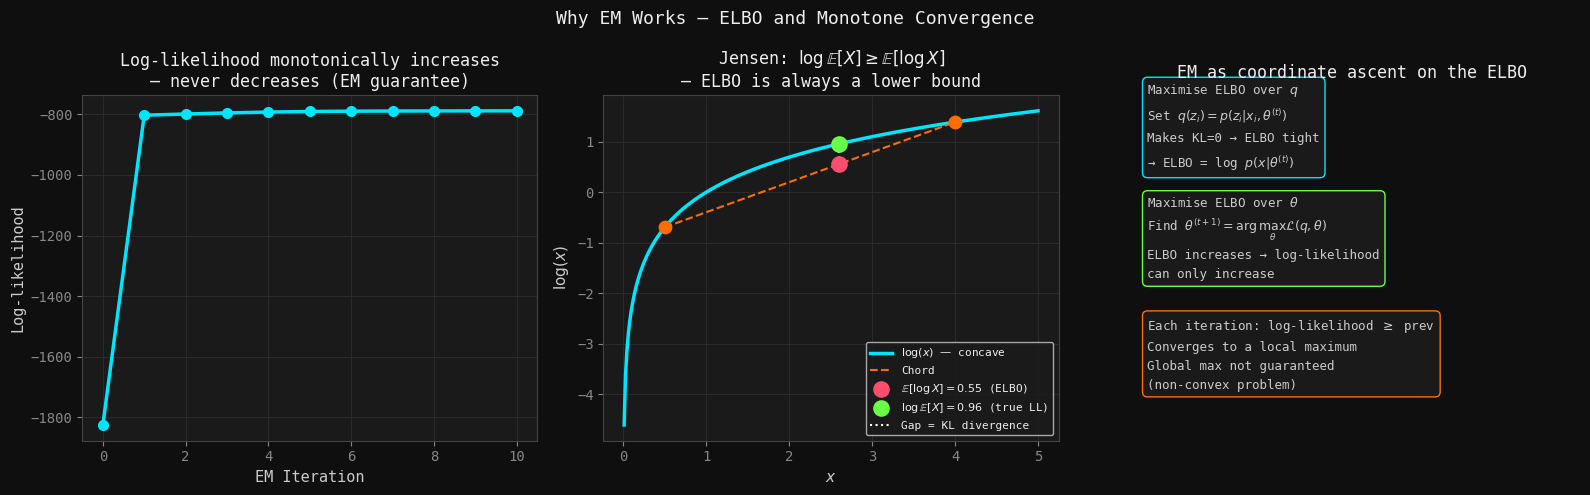

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Why EM Works — ELBO and Monotone Convergence', fontsize=13)

# Log-likelihood increasing
ax = axes[0]
ax.plot(ll_history, color=ACCENT, lw=2.5, marker='o', ms=7)
ax.set_xlabel('EM Iteration'); ax.set_ylabel('Log-likelihood')
ax.set_title('Log-likelihood monotonically increases\n— never decreases (EM guarantee)')
ax.grid(True)

# Jensen's inequality visualisation
ax = axes[1]
x_j = np.linspace(0.01, 5, 300)
ax.plot(x_j, np.log(x_j), color=ACCENT, lw=2.5, label='$\\log(x)$ — concave')
# Two points and their expectation
a_j, b_j = 0.5, 4.0
lam = 0.4
E_x = lam*a_j + (1-lam)*b_j
E_logx = lam*np.log(a_j) + (1-lam)*np.log(b_j)
log_Ex = np.log(E_x)
ax.scatter([a_j, b_j], [np.log(a_j), np.log(b_j)], color=ORANGE, s=80, zorder=5)
ax.plot([a_j, b_j], [np.log(a_j), np.log(b_j)], color=ORANGE, lw=1.5,
        linestyle='--', label='Chord')
ax.scatter(E_x, E_logx, color=RED,   s=120, zorder=6,
           label=f'$\\mathbb{{E}}[\\log X]={E_logx:.2f}$ (ELBO)')
ax.scatter(E_x, log_Ex, color=GREEN, s=120, zorder=6,
           label=f'$\\log\\mathbb{{E}}[X]={log_Ex:.2f}$ (true LL)')
ax.plot([E_x, E_x], [E_logx, log_Ex], color='white', lw=1.5,
        linestyle=':', label='Gap = KL divergence')
ax.set_xlabel('$x$'); ax.set_ylabel('$\\log(x)$')
ax.set_title("Jensen: $\\log\\mathbb{E}[X] \\geq \\mathbb{E}[\\log X]$\n— ELBO is always a lower bound")
ax.legend(fontsize=8); ax.grid(True)

# ELBO tight after E-step, increases after M-step
ax = axes[2]
ax.axis('off')
ax.set_title('EM as coordinate ascent on the ELBO', pad=12)
step_text = [
    ('E-step', 'Maximise ELBO over $q$\nSet $q(z_i) = p(z_i|x_i,\\theta^{(t)})$\nMakes KL=0 → ELBO tight\n→ ELBO = log $p(x|\\theta^{(t)})$', ACCENT),
    ('M-step', 'Maximise ELBO over $\\theta$\nFind $\\theta^{(t+1)} = \\arg\\max_\\theta \\mathcal{L}(q,\\theta)$\nELBO increases → log-likelihood\ncan only increase', GREEN),
    ('Result', 'Each iteration: log-likelihood $\\geq$ prev\nConverges to a local maximum\nGlobal max not guaranteed\n(non-convex problem)', ORANGE),
]
for i, (name, text, color) in enumerate(step_text):
    y = 0.85 - i*0.32
    ax.text(0.05, y, name, transform=ax.transAxes, color=color,
            fontsize=12, fontweight='bold')
    ax.text(0.05, y-0.06, text, transform=ax.transAxes,
            color='#ccc', fontsize=9, linespacing=1.6,
            bbox=dict(boxstyle='round,pad=0.4', facecolor='#1a1a1a', edgecolor=color))

plt.tight_layout()
plt.savefig('img/gmm04_elbo.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 5. GMM vs K-Means — Soft vs Hard Assignments

K-Means is a special case of EM for GMMs with:
- **Spherical equal covariances**: $\Sigma_k = \sigma^2 I$ for all $k$, with $\sigma^2 \to 0$
- **Hard assignments**: $r_{ik} \in \{0,1\}$ (winner-takes-all)
- **Equal mixing weights**: $\pi_k = 1/K$

As $\sigma^2 \to 0$, the Gaussian pdf becomes concentrated around the mean, and the responsibility $r_{ik} \to 1$ for the nearest centroid and $\to 0$ for all others. The M-step centroid update reduces to the cluster mean.

**Key differences in practice**:

| | K-Means | GMM |
|---|---|---|
| Assignment | Hard (binary) | Soft (probabilistic) |
| Boundary | Voronoi cells (equidistant) | Curved (shaped by covariance) |
| Cluster shape | Spherical | Arbitrary ellipse (full covariance) |
| Output | Cluster labels | Posterior probabilities $r_{ik}$ |
| Sensitive to outliers | Yes | Less so (outliers get distributed responsibility) |
| Degeneracy risk | Low | High (component collapses to a single point) |

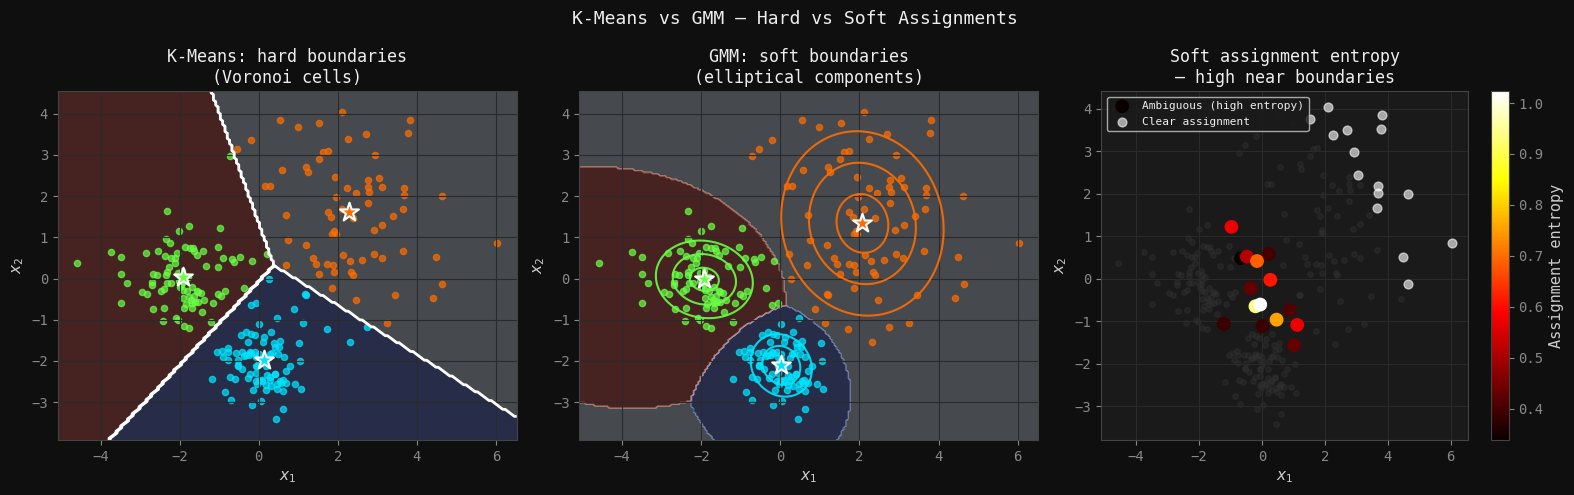

In [6]:
np.random.seed(6)
centers_cmp = [[-2,0],[2,1],[0,-2]]
X_cmp, y_cmp = make_blobs(n_samples=250, centers=centers_cmp,
                           cluster_std=[0.7,1.5,0.5], random_state=6)

from sklearn.cluster import KMeans as KM
km_cmp  = KM(n_clusters=3, random_state=0, n_init=10).fit(X_cmp)
gmm_cmp = GaussianMixture(n_components=3, covariance_type='full', random_state=0).fit(X_cmp)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('K-Means vs GMM — Hard vs Soft Assignments', fontsize=13)

xxi = np.linspace(X_cmp[:,0].min()-0.5, X_cmp[:,0].max()+0.5, 200)
yyi = np.linspace(X_cmp[:,1].min()-0.5, X_cmp[:,1].max()+0.5, 200)
XXi, YYi = np.meshgrid(xxi, yyi)

# K-Means
ax = axes[0]
Z_km = km_cmp.predict(np.c_[XXi.ravel(), YYi.ravel()]).reshape(XXi.shape)
ax.contourf(XXi, YYi, Z_km, alpha=0.25, cmap='coolwarm')
ax.contour(XXi,  YYi, Z_km, levels=[0.5,1.5], colors='white', linewidths=2)
for k in range(3):
    mask = km_cmp.labels_ == k
    ax.scatter(X_cmp[mask,0], X_cmp[mask,1], color=CLUSTER_COLORS[k], s=20, alpha=0.7)
    ax.scatter(*km_cmp.cluster_centers_[k], color=CLUSTER_COLORS[k],
               s=200, marker='*', zorder=5, edgecolors='white', linewidth=1.5)
ax.set_title('K-Means: hard boundaries\n(Voronoi cells)')
ax.set_xlabel('$x_1$'); ax.set_ylabel('$x_2$'); ax.grid(True)

# GMM
ax = axes[1]
R_gmm = gmm_cmp.predict_proba(np.c_[XXi.ravel(), YYi.ravel()])
Z_gmm = np.argmax(R_gmm, axis=1).reshape(XXi.shape)
ax.contourf(XXi, YYi, Z_gmm, alpha=0.25, cmap='coolwarm')
# GMM ellipses
for k in range(3):
    mask = gmm_cmp.predict(X_cmp) == k
    ax.scatter(X_cmp[mask,0], X_cmp[mask,1], color=CLUSTER_COLORS[k], s=20, alpha=0.7)
    mu_g  = gmm_cmp.means_[k]
    sig_g = gmm_cmp.covariances_[k]
    rv_g  = multivariate_normal(mu_g, sig_g)
    pos_g = np.dstack((XXi, YYi))
    Z_g   = rv_g.pdf(pos_g)
    ax.contour(XXi, YYi, Z_g, levels=3, colors=[CLUSTER_COLORS[k]],
               linewidths=1.5, alpha=0.9)
    ax.scatter(*mu_g, color=CLUSTER_COLORS[k], s=200, marker='*',
               zorder=5, edgecolors='white', linewidth=1.5)
ax.set_title('GMM: soft boundaries\n(elliptical components)')
ax.set_xlabel('$x_1$'); ax.set_ylabel('$x_2$'); ax.grid(True)

# Soft responsibility for a few ambiguous points
ax = axes[2]
# Find points near decision boundary
R_pts = gmm_cmp.predict_proba(X_cmp)
entropy_pts = -np.sum(R_pts * np.log(R_pts + 1e-9), axis=1)
amb_idx = np.argsort(entropy_pts)[-15:]  # most ambiguous
clear_idx = np.argsort(entropy_pts)[:15]  # clearest
ax.scatter(X_cmp[:,0], X_cmp[:,1], c='#333', s=15, alpha=0.4)
sc = ax.scatter(X_cmp[amb_idx,0], X_cmp[amb_idx,1],
                c=entropy_pts[amb_idx], cmap='hot', s=80, zorder=5,
                label='Ambiguous (high entropy)')
plt.colorbar(sc, ax=ax, label='Assignment entropy')
ax.scatter(X_cmp[clear_idx,0], X_cmp[clear_idx,1],
           c='white', s=40, zorder=4, alpha=0.6, label='Clear assignment')
ax.set_title('Soft assignment entropy\n— high near boundaries')
ax.set_xlabel('$x_1$'); ax.set_ylabel('$x_2$')
ax.legend(fontsize=8); ax.grid(True)

plt.tight_layout()
plt.savefig('img/gmm05_vs_kmeans.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 6. Model Selection — BIC & AIC

The log-likelihood always increases with more components — we need to penalise model complexity.

**AIC** — Akaike Information Criterion:
$$\text{AIC} = 2d - 2\log\hat{\mathcal{L}}$$

**BIC** — Bayesian Information Criterion:
$$\text{BIC} = d\log n - 2\log\hat{\mathcal{L}}$$

where:
- $d$ — number of free parameters
- $\log\hat{\mathcal{L}}$ — maximised log-likelihood
- $n$ — number of samples

**Lower is better** for both. BIC penalises complexity more heavily (the $\log n$ factor grows with data size), so it tends to select simpler models.

**Number of parameters for a GMM with $K$ components in $\mathbb{R}^p$**:
- Mixing weights: $K-1$ (they sum to 1)
- Means: $Kp$
- Covariances (full): $K\frac{p(p+1)}{2}$
- Total: $d = (K-1) + Kp + K\frac{p(p+1)}{2}$

**Derivation of BIC**: BIC approximates the Bayesian model evidence $\log p(\mathcal{D} | M)$ using a Laplace approximation around the MLE. The penalty $d\log n$ accounts for the cost of estimating $d$ parameters from $n$ data points.

NameError: name 'WHITE' is not defined

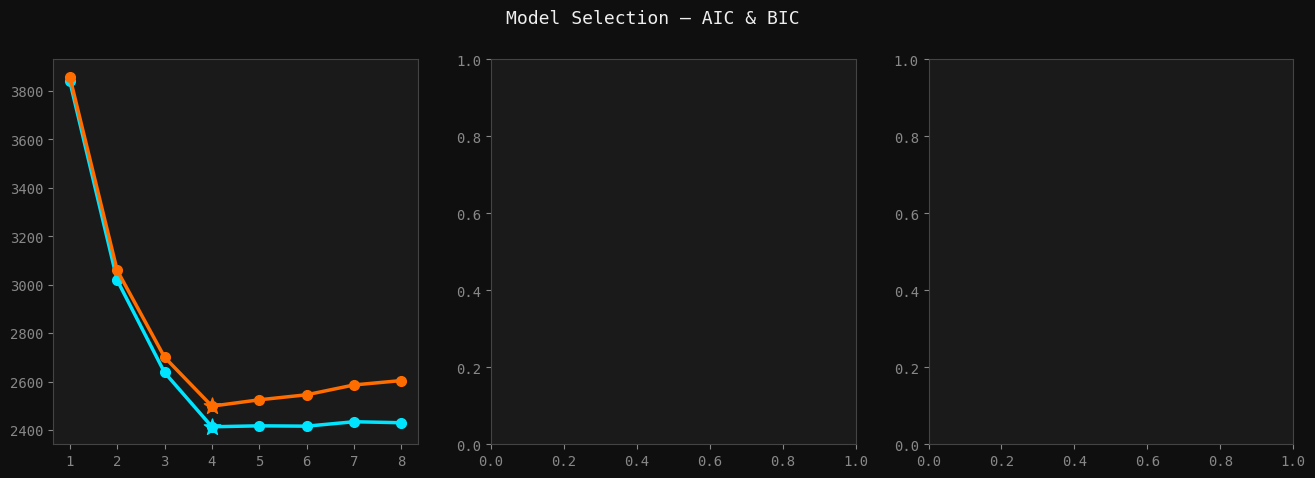

In [7]:
np.random.seed(7)
X_bic, _ = make_blobs(n_samples=300, centers=4, cluster_std=0.9, random_state=7)

k_range_bic = range(1, 9)
aic_vals, bic_vals, ll_vals = [], [], []
for k in k_range_bic:
    gm = GaussianMixture(n_components=k, covariance_type='full',
                          n_init=5, random_state=0)
    gm.fit(X_bic)
    aic_vals.append(gm.aic(X_bic))
    bic_vals.append(gm.bic(X_bic))
    ll_vals.append(gm.score(X_bic) * len(X_bic))

best_k_bic = list(k_range_bic)[np.argmin(bic_vals)]
best_k_aic = list(k_range_bic)[np.argmin(aic_vals)]

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Model Selection — AIC & BIC', fontsize=13)

# AIC and BIC
ax = axes[0]
ax.plot(list(k_range_bic), aic_vals, color=ACCENT,  lw=2.5, marker='o', ms=7, label='AIC')
ax.plot(list(k_range_bic), bic_vals, color=ORANGE, lw=2.5, marker='o', ms=7, label='BIC')
ax.scatter(best_k_aic, aic_vals[best_k_aic-1], color=ACCENT, s=150, zorder=5, marker='*')
ax.scatter(best_k_bic, bic_vals[best_k_bic-1], color=ORANGE, s=150, zorder=5, marker='*')
ax.axvline(best_k_bic, color=WHITE, lw=1.5, linestyle='--',
           label=f'BIC selects K={best_k_bic}')
ax.set_xlabel('K'); ax.set_ylabel('Criterion (lower = better)')
ax.set_title('AIC and BIC — both penalise complexity\nBIC prefers simpler models')
ax.legend(fontsize=9); ax.grid(True)

# Log-likelihood vs penalty
ax = axes[1]
norm_ll  = np.array(ll_vals) / abs(ll_vals[0])
norm_bic = np.array(bic_vals) / abs(bic_vals[0])
penalty_bic = np.array([gm_par(k, 2) * np.log(len(X_bic))
                         for k in k_range_bic]) / abs(ll_vals[0])
def gm_par(k, p): return (k-1) + k*p + k*p*(p+1)//2
penalties = np.array([gm_par(k, 2) * np.log(len(X_bic)) for k in k_range_bic])
ax.plot(list(k_range_bic), -np.array(ll_vals), color=GREEN,  lw=2.5, label='-Log-likelihood (decreases)')
ax.plot(list(k_range_bic), penalties,           color=RED,    lw=2.5, linestyle='--', label='BIC penalty $d\\log n$')
ax.plot(list(k_range_bic), bic_vals,            color=ORANGE, lw=2.5, label='BIC = both combined')
ax.set_xlabel('K'); ax.set_ylabel('Value')
ax.set_title('BIC = -2 log-likelihood + $d\\log n$\nBest K where they balance')
ax.legend(fontsize=9); ax.grid(True)

# Number of parameters vs K
ax = axes[2]
p_dim = 2
params = [gm_par(k, p_dim) for k in k_range_bic]
bars = ax.bar(list(k_range_bic), params, color=PURPLE, alpha=0.8)
for bar, val in zip(bars, params):
    ax.text(bar.get_x()+bar.get_width()/2, val+0.3,
            str(val), ha='center', fontsize=10, color='white')
ax.set_xlabel('K'); ax.set_ylabel('Number of free parameters $d$')
ax.set_title(f'Parameters grow as $\\sim K(p^2/2)$\n(2D data: $p={p_dim}$)')
ax.grid(True, axis='y')

plt.tight_layout()
plt.savefig('img/gmm06_bic_aic.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 7. Practical Considerations & Limitations

### Singularities — The Degeneracy Problem

If a Gaussian component collapses onto a single data point, its variance $\sigma_k^2 \to 0$ and the likelihood $\to \infty$. This is a **singularity** — the log-likelihood is unbounded above. EM may converge to these degenerate solutions.

Fix: regularise the covariance matrix by adding a small constant to the diagonal:
$$\Sigma_k \leftarrow \Sigma_k + \epsilon I, \quad \epsilon \approx 10^{-6}$$

sklearn does this automatically via the `reg_covar` parameter.

### Label Switching

GMMs are **identifiable only up to permutation** of component labels — swapping component 1 and component 2 gives the same joint likelihood. This makes it impossible to track "component 1" across runs or to average parameters over multiple runs.

### Sensitivity to Initialisation

Like K-Means, EM can converge to different local maxima from different starting points. Best practice: `n_init=10` (run 10 times, keep the highest log-likelihood).

In [ ]:
np.random.seed(8)
X_prac, _ = make_blobs(n_samples=300, centers=3, cluster_std=0.9, random_state=8)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Practical Considerations — Singularities, Restarts, Covariance Types', fontsize=13)

# Multiple restarts: LL distribution
ax = axes[0]
ll_restarts = []
for seed in range(40):
    gm_r = GaussianMixture(n_components=3, n_init=1, random_state=seed)
    gm_r.fit(X_prac)
    ll_restarts.append(gm_r.score(X_prac) * len(X_prac))
ax.hist(ll_restarts, bins=15, color=ACCENT, alpha=0.8)
ax.axvline(max(ll_restarts), color=GREEN, lw=2, linestyle='--',
           label=f'Best LL={max(ll_restarts):.1f}')
ax.axvline(np.mean(ll_restarts), color=ORANGE, lw=2, linestyle=':',
           label=f'Mean LL={np.mean(ll_restarts):.1f}')
ax.set_xlabel('Final log-likelihood'); ax.set_ylabel('Count')
ax.set_title('40 random restarts — LL varies\nn_init=10 picks the best')
ax.legend(fontsize=9); ax.grid(True)

# Covariance type comparison
ax = axes[1]
cov_types = ['spherical', 'diag', 'tied', 'full']
bic_cov   = []
for ct in cov_types:
    gm_ct = GaussianMixture(n_components=3, covariance_type=ct,
                             n_init=5, random_state=0)
    gm_ct.fit(X_prac)
    bic_cov.append(gm_ct.bic(X_prac))
bars = ax.bar(cov_types, bic_cov,
              color=[RED, ORANGE, GREEN, ACCENT], alpha=0.8)
for bar, val in zip(bars, bic_cov):
    ax.text(bar.get_x()+bar.get_width()/2, val+5,
            f'{val:.0f}', ha='center', fontsize=10, color='white')
ax.set_xlabel('Covariance type'); ax.set_ylabel('BIC (lower = better)')
ax.set_title('Covariance type tradeoff\nFull is best but uses most parameters')
ax.grid(True, axis='y')

# EM vs K-Means log-likelihood convergence
ax = axes[2]
gm_conv = GaussianMixture(n_components=3, n_init=1, max_iter=50,
                            warm_start=False, random_state=0)
gm_conv.fit(X_prac)
# Approximate LL per iteration using staged EM
lls_em = []
gm_stage = GaussianMixture(n_components=3, n_init=1, max_iter=1, random_state=0)
gm_stage.fit(X_prac)
for it in range(30):
    lls_em.append(gm_stage.score(X_prac) * len(X_prac))
    gm_stage.max_iter += 1
    gm_stage.warm_start = True
    gm_stage.fit(X_prac)
ax.plot(lls_em, color=GREEN, lw=2.5, label='GMM (EM)')
ax.set_xlabel('Iteration'); ax.set_ylabel('Log-likelihood')
ax.set_title('EM convergence: monotone increase\n(guaranteed by Jensen)')
ax.legend(fontsize=9); ax.grid(True)

plt.tight_layout()
plt.savefig('img/gmm07_practical.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Key Takeaways

1. A GMM models $p(x) = \sum_k \pi_k \mathcal{N}(x; \mu_k, \Sigma_k)$ — a weighted sum of Gaussians. Each point has a latent component assignment $z_i$.
2. The log-likelihood $\sum_i \log\sum_k \pi_k \mathcal{N}(x_i; \mu_k, \Sigma_k)$ has no closed-form maximiser because of the **log of a sum**. The M-step equations are coupled through the responsibilities $r_{ik}$.
3. **EM alternates** between the E-step (compute $r_{ik} = P(z_i=k|x_i,\theta)$) and M-step (update $\pi_k, \mu_k, \Sigma_k$ using $r_{ik}$ as soft weights).
4. **EM is guaranteed to increase the log-likelihood** at each step — proven via Jensen's inequality and the ELBO. It converges to a local maximum, not necessarily global.
5. **K-Means is a special case** of GMM EM with spherical equal covariances and $\sigma^2 \to 0$, which forces hard assignments $r_{ik} \in \{0,1\}$.
6. **BIC** $= d\log n - 2\log\hat{\mathcal{L}}$ penalises model complexity. Use it to choose $K$ — minimum BIC balances fit and complexity.
7. Watch out for **singularities** (component collapses onto one point) and **label switching** (permutation ambiguity). Use `reg_covar` and `n_init` in sklearn.

---
*Previous: [`07_kmeans.ipynb`](./07_kmeans.ipynb) · Back to [`README.md`](./README.md)*